# Cài đặt library và dữ liệu

In [2]:
# !pip install ydata_profiling
# !pip install sweetviz
# !pip install AutoViz
# !pip install dtale
#!wget -O "data.zip" "https://drive.google.com/uc?export=download&id=1fOFKzMnQv-udo0pHn1N7FzzKiF0Uifoh" && unzip "data.zip"

import pandas as pd  #for data manipulation operations
import numpy as np  #for numeric operations on data
import seaborn as sns  #for data visualization operations
import matplotlib.pyplot as plt  #for data visualization operations
from scipy import stats  #for statistical operations
from data_profiling import ProfileReport
import dtale

In [ ]:
marketing_data = pd.read_csv("data/customer-personality-analysis.csv")
online_retail = pd.read_excel("data/eda-online-retail.xlsx")
diabetes = pd.read_csv("data/pima-indians-diabetes-eda-prediction-0-906.csv")
wine = pd.read_csv("data/red-wine-quality-eda-classification.csv")
penguins_data = pd.read_csv("data/penguins_lter.csv")
houseprices_data = pd.read_csv("data/HousingPrices-Amsterdam-August-2021.csv")


# 1.1 THỐNG KÊ MÔ TẢ

## 1.1.1 Ôn tập lý thuyết

**Q1: Thống kê mô tả là gì? Nó khác gì với thống kê suy luận (inferential statistics)?**  
A1: Thống kê mô tả là phương pháp tóm tắt, mô tả và trình bày dữ liệu bằng các chỉ số, bảng, biểu đồ, giúp hiểu nhanh cấu trúc dữ liệu. Thống kê suy luận dùng mẫu để suy luận về tổng thể, áp dụng kiểm định giả thuyết, ước lượng tham số hoặc hồi quy.

---

**Q2: Các thước đo thống kê mô tả chính (ví dụ: trung bình, trung vị, phương sai, độ lệch chuẩn) được sử dụng để làm gì? Trong trường hợp nào thì nên dùng trung vị thay vì trung bình?**  
A2:  
- Trung bình: đo giá trị trung tâm, dùng khi dữ liệu phân bố chuẩn, không có outlier.  
- Trung vị: đo giá trị ở giữa, dùng khi dữ liệu lệch hoặc có outlier.  
- Phương sai, độ lệch chuẩn: đo mức độ phân tán quanh trung bình.  
- Min/Max, Range: đo phạm vi trải rộng dữ liệu.  
- Q1, Q3: đánh giá phân bố và outlier.  

---

**Q3: Làm thế nào để xác định phân bố của một tập dữ liệu? Các loại phân bố phổ biến là gì (ví dụ: phân bố chuẩn, lệch trái, lệch phải)?**  
A3: Quan sát histogram, boxplot hoặc dùng kiểm định thống kê (Shapiro-Wilk, Kolmogorov-Smirnov). Các phân bố phổ biến: chuẩn, lệch trái, lệch phải, đồng đều.

---

**Q4: Độ lệch chuẩn và phạm vi (range) có ý nghĩa gì trong việc đánh giá sự phân tán của dữ liệu?**  
A4:  
- Độ lệch chuẩn: đo mức độ dữ liệu phân tán quanh trung bình; giá trị lớn → phân tán nhiều.  
- Phạm vi: khoảng cách giữa giá trị cực đại và cực tiểu, cho thấy mức trải rộng dữ liệu.

---

**Q5: Sự khác biệt giữa các thước đo như Q1, Q2, Q3 trong biểu đồ hộp (boxplot) là gì?**  
A5:  
- Q1 (25%): 25% dữ liệu nhỏ hơn hoặc bằng Q1.  
- Q2 (50%) = Median: 50% dữ liệu nhỏ hơn hoặc bằng Q2.  
- Q3 (75%): 75% dữ liệu nhỏ hơn hoặc bằng Q3.  
- IQR = Q3 - Q1, dùng để xác định outlier.

---

**Q6: Làm thế nào để xử lý giá trị thiếu (missing values) trước khi tính toán các chỉ số thống kê mô tả?**  
A6: Có thể:  
- Loại bỏ bản ghi chứa giá trị thiếu.  
- Thay bằng trung bình, trung vị hoặc dự đoán giá trị.  
- Chọn phương pháp tùy thuộc vào loại dữ liệu và mục tiêu phân tích.

---

**Q7: Bạn có thể giải thích cách đọc và diễn giải một biểu đồ histogram hoặc boxplot từ dữ liệu thực tế không?**  
A7:  
- Histogram: quan sát tần suất xuất hiện của giá trị, hình dạng phân bố, lệch trái/phải, nhiều đỉnh.  
- Boxplot: quan sát phân vị, giá trị ngoại lai, độ lệch và so sánh nhiều nhóm dữ liệu.

---

**Q8: Khi gặp một tập dữ liệu có giá trị ngoại lai (outliers), bạn sẽ xử lý chúng như thế nào trước khi thực hiện thống kê mô tả?**  
A8:  
- Nhận biết outlier: dữ liệu nằm ngoài Q1 - 1.5*IQR hoặc Q3 + 1.5*IQR.  
- Xử lý:  
  - Loại bỏ nếu là lỗi đo lường.  
  - Giữ lại nếu phản ánh hiện thực.  
  - Biến đổi dữ liệu (log, sqrt) để giảm ảnh hưởng.

## 1.1.3. Bài tập thực hành 1

+ Thực hiện thống kê mô tả trên tập dữ liệu về phân loại chất lượng rượu đỏ.
Dữ liệu lấy tại https://www.kaggle.com/code/eisgandar/red-wine-quality-eda-classification

In [ ]:
def analyze(df):
    for col in df.columns:
        if np.issubdtype(df[col].dtype, np.number):

            print(f"""
Column: {col}

Mean: {np.mean(df[col])}
Median: {np.median(df[col])}
Mode: {stats.mode(df[col], keepdims=True).mode[0]}
Variance: {np.var(df[col])}
Std Dev: {np.std(df[col])}
Max: {np.max(df[col])}
Min: {np.min(df[col])}
60th Percentile: {np.percentile(df[col], 60)}
75th Percentile: {np.percentile(df[col], 75)}
Range: {np.max(df[col]) - np.min(df[col])}
IQR: {stats.iqr(df[col])}
Skewness: {stats.skew(df[col])}
Kurtosis: {stats.kurtosis(df[col])}

-----------------------------------
""")

    print("\n===== df.describe().T (CHECK) =====")
    display(df.describe().T.style.background_gradient(cmap = "magma_r"))


In [ ]:
print("\n===== wine =====")
analyze(wine)


===== wine =====

Column: fixed acidity

Mean: 8.31963727329581
Median: 7.9
Mode: 7.2
Variance: 3.0295205688671114
Std Dev: 1.7405518001102729
Max: 15.9
Min: 4.6
60th Percentile: 8.3
75th Percentile: 9.2
Range: 11.3
IQR: 2.0999999999999996
Skewness: 0.9818292953262073
Kurtosis: 1.1248563352037486

-----------------------------------


Column: volatile acidity

Mean: 0.5278205128205128
Median: 0.52
Mode: 0.6
Variance: 0.0320423261333205
Std Dev: 0.17900370424469014
Max: 1.58
Min: 0.12
60th Percentile: 0.57
75th Percentile: 0.64
Range: 1.46
IQR: 0.25
Skewness: 0.6709623963499574
Kurtosis: 1.2179633893005306

-----------------------------------


Column: citric acid

Mean: 0.2709756097560976
Median: 0.26
Mode: 0.0
Variance: 0.03792375112494089
Std Dev: 0.19474021445233364
Max: 1.0
Min: 0.0
60th Percentile: 0.32
75th Percentile: 0.42
Range: 1.0
IQR: 0.32999999999999996
Skewness: 0.3180385895475358
Kurtosis: -0.7902825153036646

-----------------------------------


Column: residual sugar


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.000000,8.319637,1.741096,4.600000,7.100000,7.900000,9.200000,15.900000
volatile acidity,1599.000000,0.527821,0.179060,0.120000,0.390000,0.520000,0.640000,1.580000
citric acid,1599.000000,0.270976,0.194801,0.000000,0.090000,0.260000,0.420000,1.000000
residual sugar,1599.000000,2.538806,1.409928,0.900000,1.900000,2.200000,2.600000,15.500000
chlorides,1599.000000,0.087467,0.047065,0.012000,0.070000,0.079000,0.090000,0.611000
free sulfur dioxide,1599.000000,15.874922,10.460157,1.000000,7.000000,14.000000,21.000000,72.000000
total sulfur dioxide,1599.000000,46.467792,32.895324,6.000000,22.000000,38.000000,62.000000,289.000000
density,1599.000000,0.996747,0.001887,0.990070,0.995600,0.996750,0.997835,1.003690
pH,1599.000000,3.311113,0.154386,2.740000,3.210000,3.310000,3.400000,4.010000
sulphates,1599.000000,0.658149,0.169507,0.330000,0.550000,0.620000,0.730000,2.000000


## 1.1.4. Bài tập thực hành 2

+ Thực hiện thống kê mô tả trên tập dữ liệu về bệnh tiểu đường. Dữ liệu lấy tại
https://www.kaggle.com/code/vincentlugat/pima-indians-diabetes-eda-prediction-0-906

In [ ]:
print("\n===== diabetes =====")
analyze(diabetes)


===== diabetes =====

Column: Pregnancies

Mean: 3.8450520833333335
Median: 3.0
Mode: 1
Variance: 11.339272393120657
Std Dev: 3.3673836124089958
Max: 17
Min: 0
60th Percentile: 4.0
75th Percentile: 6.0
Range: 17
IQR: 5.0
Skewness: 0.8999119408414357
Kurtosis: 0.15038273760948462

-----------------------------------


Column: Glucose

Mean: 120.89453125
Median: 117.0
Mode: 99
Variance: 1020.9172617594401
Std Dev: 31.95179590820272
Max: 199
Min: 0
60th Percentile: 125.0
75th Percentile: 140.25
Range: 199
IQR: 41.25
Skewness: 0.17341395519987735
Kurtosis: 0.6288133337300685

-----------------------------------


Column: BloodPressure

Mean: 69.10546875
Median: 72.0
Mode: 70
Variance: 374.1594492594401
Std Dev: 19.343201628981696
Max: 122
Min: 0
60th Percentile: 74.0
75th Percentile: 80.0
Range: 122
IQR: 18.0
Skewness: -1.8400052311728738
Kurtosis: 5.138690662525438

-----------------------------------


Column: SkinThickness

Mean: 20.536458333333332
Median: 23.0
Mode: 0
Variance: 254.14

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000000,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,768.000000,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BloodPressure,768.000000,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,768.000000,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,768.000000,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,768.000000,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
DiabetesPedigreeFunction,768.000000,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.000000,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Outcome,768.000000,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.000000


# 1.2 XỬ LÝ VÀ TRỰC QUAN HÓA DỮ LIỆU

## 1.2.1 Ôn tập lý thuyết

**Q1: Trực quan hóa dữ liệu có vai trò gì trong phân tích dữ liệu? Tại sao nó quan trọng trong khám phá dữ liệu (EDA)?**  
A1: Trực quan hóa dữ liệu giúp hiểu nhanh cấu trúc và mối quan hệ trong dữ liệu, nhận biết xu hướng, mẫu, bất thường, outlier, phân bố và tương quan giữa các biến. Trong EDA, trực quan hóa quan trọng vì nó giúp phát hiện vấn đề tiềm ẩn và đưa ra giả thuyết cho phân tích tiếp theo.

---

**Q2: Các loại biểu đồ phổ biến (như histogram, scatter plot, boxplot, bar chart) được sử dụng trong các trường hợp nào?**  
A2:  
- **Histogram**: Phân bố dữ liệu số, tần suất xuất hiện.  
- **Scatter plot**: Mối quan hệ giữa hai biến số.  
- **Boxplot**: Phân bố, trung vị, phân vị, giá trị ngoại lai.  
- **Bar chart**: So sánh giá trị giữa các nhóm phân loại.  

---

**Q3: Làm thế nào để chọn loại biểu đồ phù hợp với đặc điểm của dữ liệu (ví dụ: dữ liệu phân loại, dữ liệu số, dữ liệu thời gian)?**  
A3:  
- Dữ liệu **số (numeric)**: Histogram, boxplot, line plot (nếu theo thời gian).  
- Dữ liệu **phân loại (categorical)**: Bar chart, pie chart.  
- Dữ liệu **thời gian (time series)**: Line plot, area chart.  
- Lưu ý: Chọn biểu đồ phản ánh rõ nhất thông tin cần truyền đạt.

---

**Q4: Sự khác biệt giữa các thư viện trực quan hóa trong Python như Matplotlib, Seaborn và Plotly là gì?**  
A4:  
- **Matplotlib**: Thư viện cơ bản, linh hoạt, vẽ hầu hết loại biểu đồ nhưng cần nhiều code.  
- **Seaborn**: Dựa trên Matplotlib, trực quan đẹp hơn, hỗ trợ thống kê (hue, boxplot, violin, pairplot…).  
- **Plotly**: Biểu đồ tương tác, xuất web dễ dàng, có thể zoom, hover, tooltip, phù hợp báo cáo online.  

---

**Q5: Những nguyên tắc thiết kế nào cần tuân thủ để tạo ra một biểu đồ trực quan hóa dễ hiểu và hiệu quả?**  
A5:  
- Giữ biểu đồ **đơn giản, rõ ràng**, không quá nhiều chi tiết.  
- Có **tiêu đề, trục, nhãn và đơn vị** rõ ràng.  
- Dùng **màu sắc hợp lý**, tránh quá nhiều màu gây rối.  
- Trình bày dữ liệu theo **thứ tự hợp lý**, ví dụ từ nhỏ → lớn.  
- Tránh **hiệu ứng gây hiểu nhầm**, tỉ lệ trục x và y nên hợp lý.  

---

**Q6: Làm thế nào để tạo một biểu đồ đơn giản như histogram hoặc bar chart bằng Matplotlib?**  
A6: Dễ dàng thực hiện bằng các hàm cơ bản của Matplotlib. Cần xác định: dữ liệu, loại biểu đồ, nhãn trục và tiêu đề. (Chi tiết code không yêu cầu ở đây).

---

**Q7: Làm thế nào để xuất biểu đồ từ Python ra các định dạng như PNG, PDF hoặc HTML để sử dụng trong báo cáo?**  
A7:  
- Có thể lưu trực tiếp từ thư viện Matplotlib/Seaborn bằng các hàm xuất file: PNG, JPG, PDF.  
- Với Plotly, biểu đồ có thể xuất sang HTML để duy trì tính tương tác.  
- Luôn đặt tên file và thư mục lưu hợp lý để quản lý báo cáo dễ dàng.  

## 1.2.2. Bài làm mẫu

### 2. Trực quan hóa dữ liệu với thư viện Matplotlib

In [ ]:
import pandas as pd  #for data manipulation operations
import numpy as np  #for numeric operations on data
import seaborn as sns  #for data visualization operations
import matplotlib.pyplot as plt  #for data visualization operations
from scipy import stats  #for statistical operations

#houseprices_data = pd.read_csv("https://drive.google.com/uc?id=1R2fD4P0kxm-jupWrhOZbZGrbmLJRpcgG")
houseprices_data.head()
houseprices_data = houseprices_data[['Zip', 'Price', 'Area', 'Room']]

# Create a PriceperSqm variable based on the Price and Area variables:
houseprices_data['PriceperSqm'] = houseprices_data['Price']/houseprices_data['Area']
houseprices_sorted = houseprices_data.sort_values(by=['PriceperSqm'], ascending=False)
houseprices_sorted.head()

,Zip,Price,Area,Room,PriceperSqm
179,1012 JS,4495000.0,178,5,25252.808989
206,1018 VG,1050000.0,63,3,16666.666667
210,1087 SM,400000.0,25,2,16000.000000
280,1017 AD,2325000.0,150,6,15500.000000
195,1017 EL,5950000.0,394,10,15101.522843


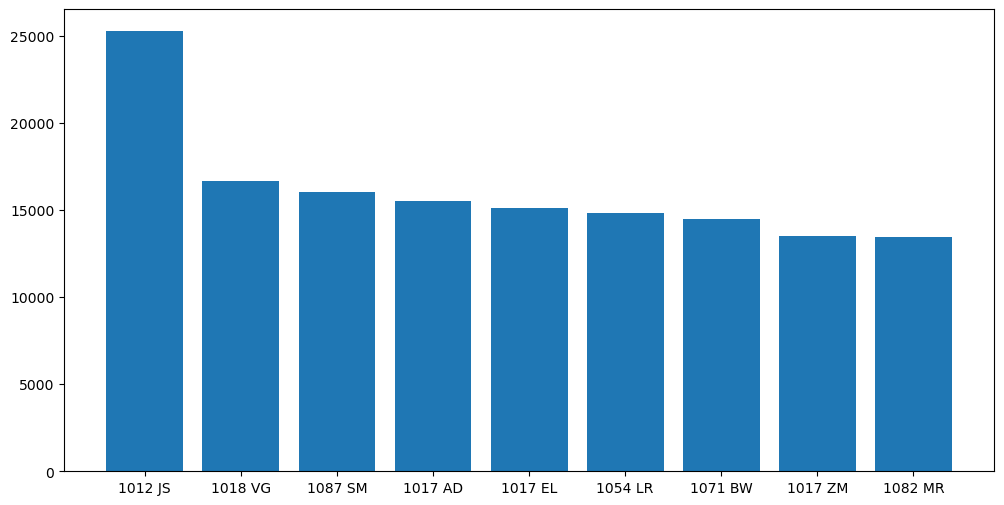

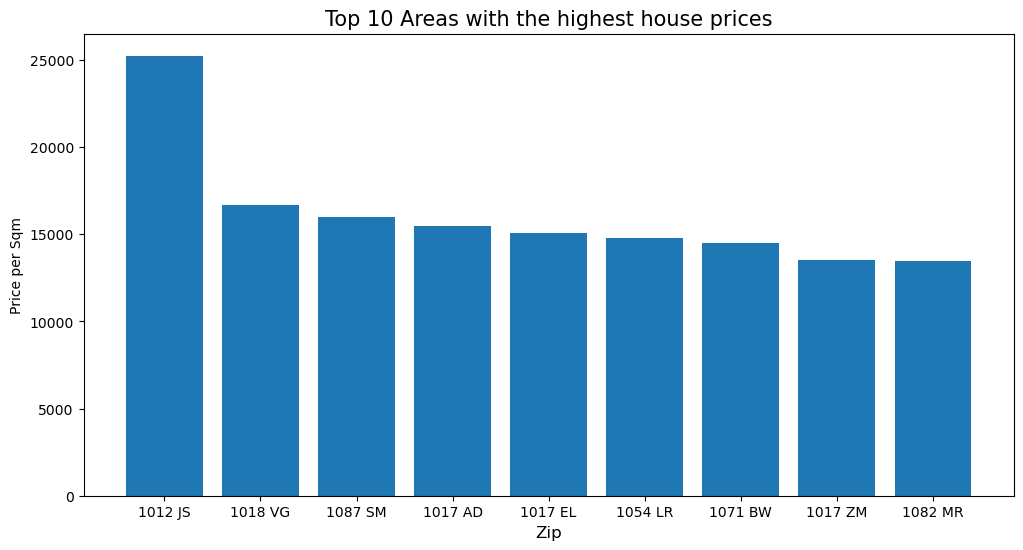

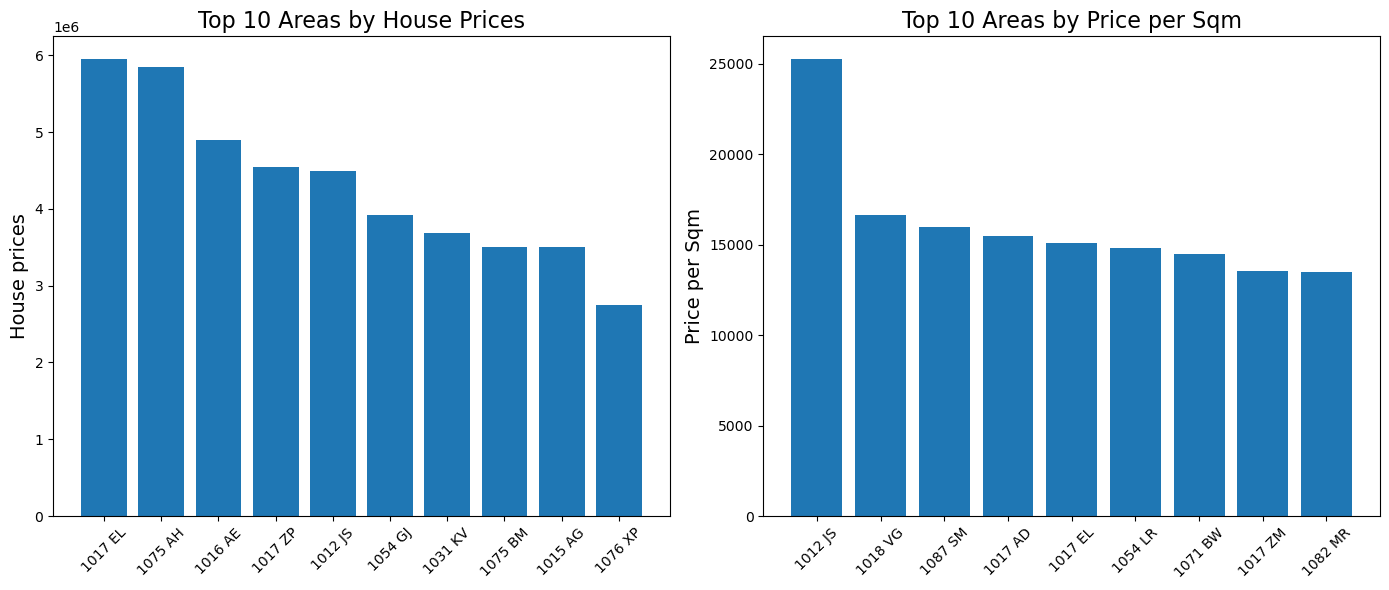

In [ ]:
# case 1: basic
plt.figure(figsize=(12,6))
x = houseprices_sorted['Zip'][0:10]
y = houseprices_sorted['PriceperSqm'][0:10]
plt.bar(x,y)
plt.show()

# case 2: advanced 1
plt.figure(figsize=(12,6))
plt.bar(x,y)
plt.title("Top 10 Areas with the highest house prices", fontsize = 15)
plt.xlabel("Zip", fontsize=12)
plt.xticks(fontsize=10)
plt.ylabel("Price per Sqm")
plt.yticks(fontsize=10)
#plt.tight_layout(rect=[0, 0, 1, 0.8])  # leaves 5% at the top for the title
plt.show()

# case 3: advanced 2
plt.figure(figsize=(14,6))
# Left plot: Top 10 by Price
plt.subplot(1,2,1)
plt.bar(
    houseprices_data.nlargest(10, 'Price')['Zip'],
    houseprices_data.nlargest(10, 'Price')['Price']
)
plt.xticks(rotation=45, fontsize=10)
plt.ylabel("House prices", fontsize=14)
plt.title("Top 10 Areas by House Prices", fontsize=16)
# Right plot: Top 10 by Price per Sqm
plt.subplot(1,2,2)
plt.bar(
    houseprices_data.nlargest(10, 'PriceperSqm')['Zip'],
    houseprices_data.nlargest(10, 'PriceperSqm')['PriceperSqm']
)
plt.xticks(rotation=45, fontsize=10)
plt.ylabel("Price per Sqm", fontsize=14)
plt.title("Top 10 Areas by Price per Sqm", fontsize=16)

plt.tight_layout()
plt.show()

### 3. Trực quan hóa dữ liệu với thư viện Seaborn

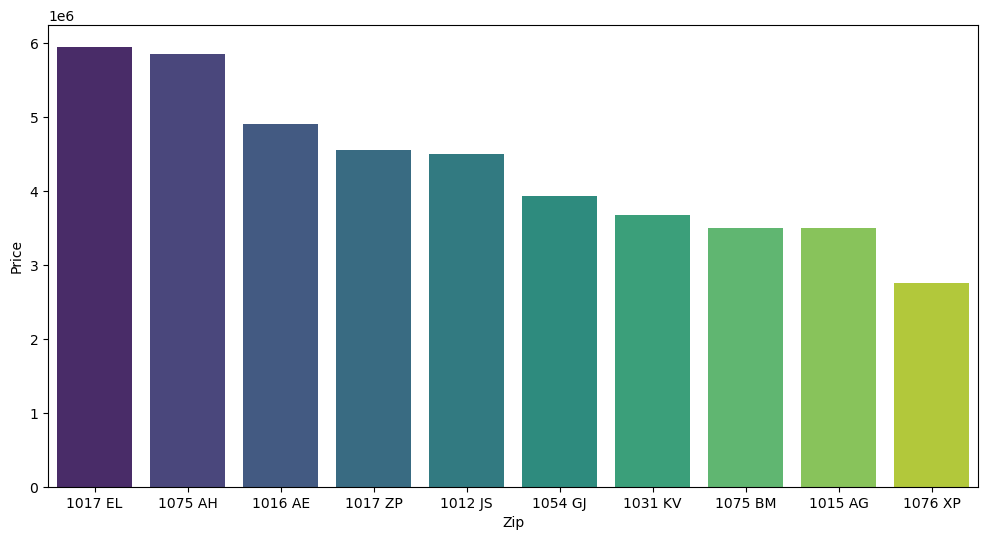

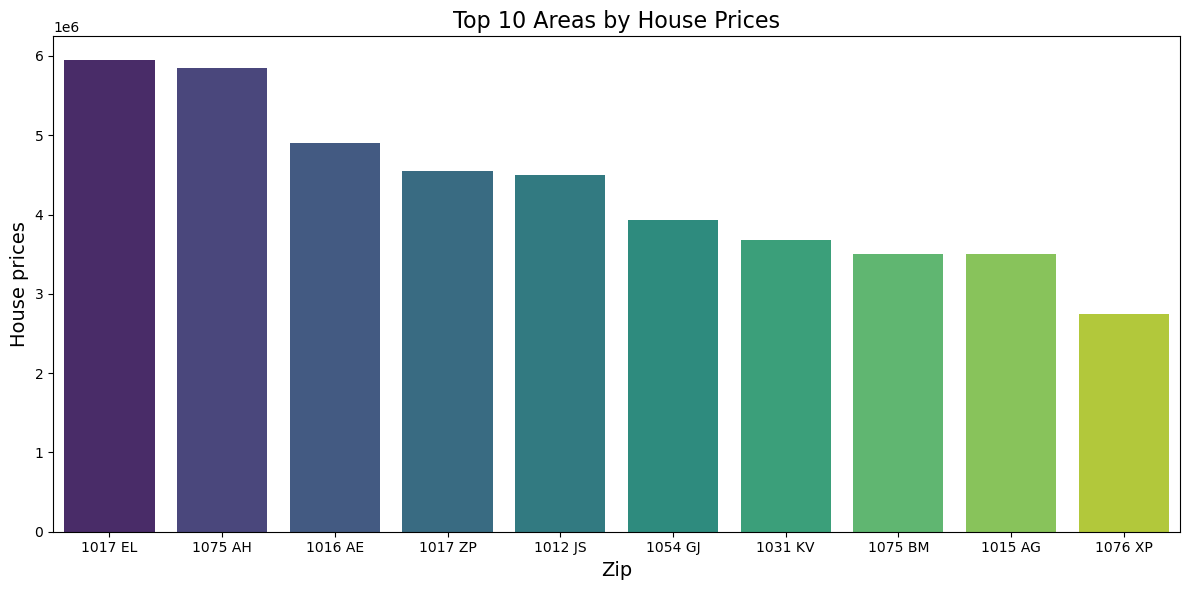

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# case 1: basic
plt.figure(figsize= (12,6))
data_price = houseprices_data.nlargest(10, 'Price')
sns.barplot(data=data_price, x='Zip', y='Price',hue='Zip',  palette="viridis")
plt.show()

# case 2: advanced
plt.figure(figsize=(12,6))
ax = sns.barplot(data=data_price, x='Zip', y='Price',hue='Zip',  palette="viridis")
ax.set_title("Top 10 Areas by House Prices", fontsize=16)
ax.set_xlabel("Zip", fontsize=14)
ax.set_ylabel("House prices", fontsize=14)
plt.tight_layout()
plt.show()


## 1.2.2. Bài tập thực hành 1
+ Thực hiện trực quan hóa dữ liệu trên tập dữ liệu về phân loại chất lượng rượu đỏ. Dữ liệu lấy tại
https://www.kaggle.com/code/eisgandar/red-wine-quality-eda-classification

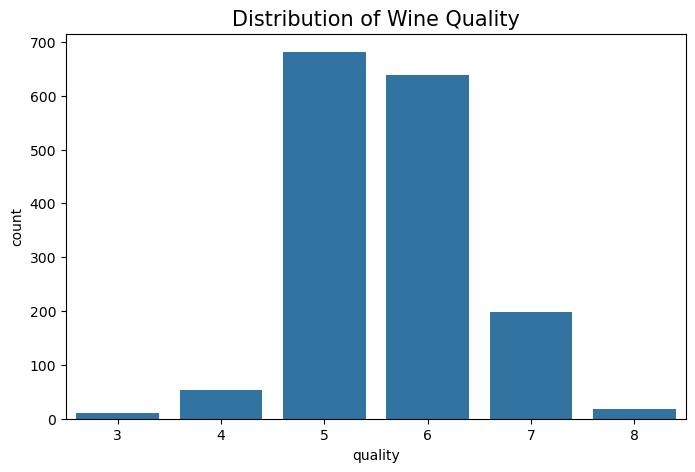

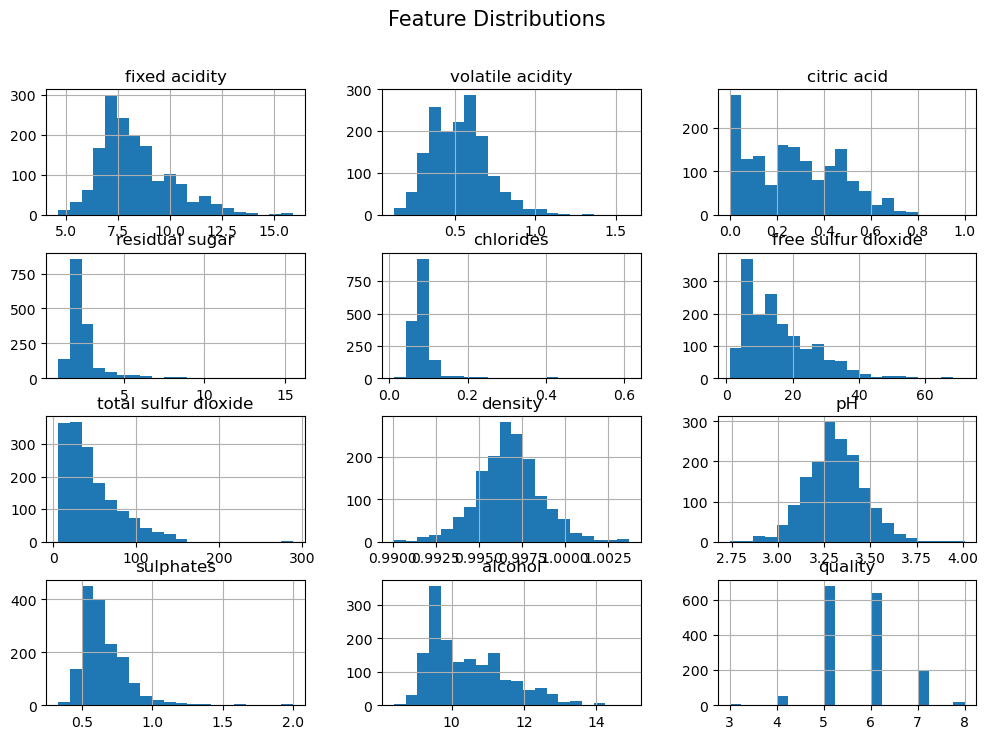

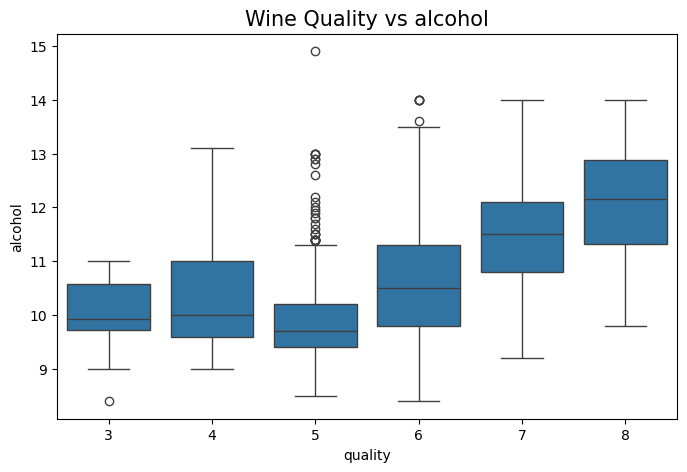

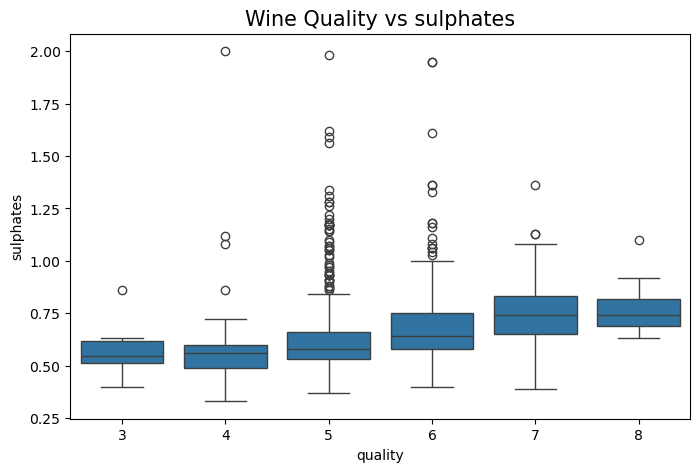

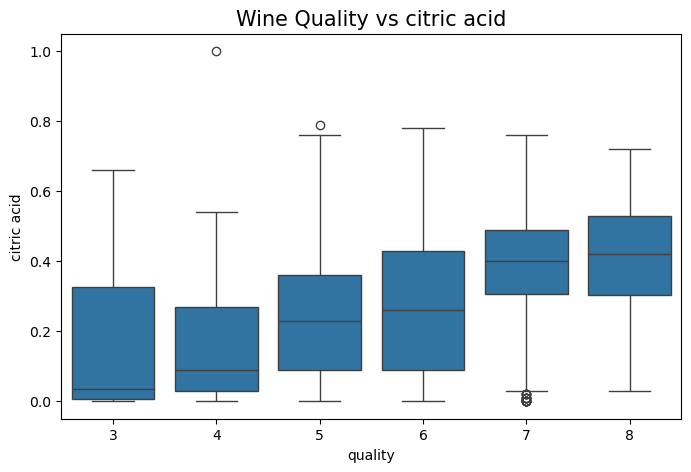

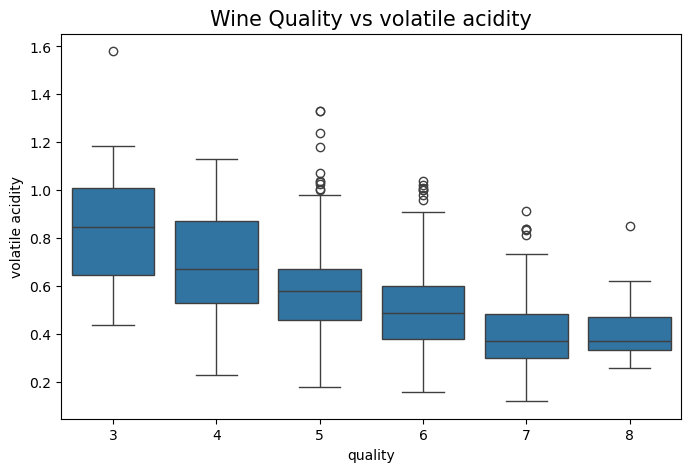

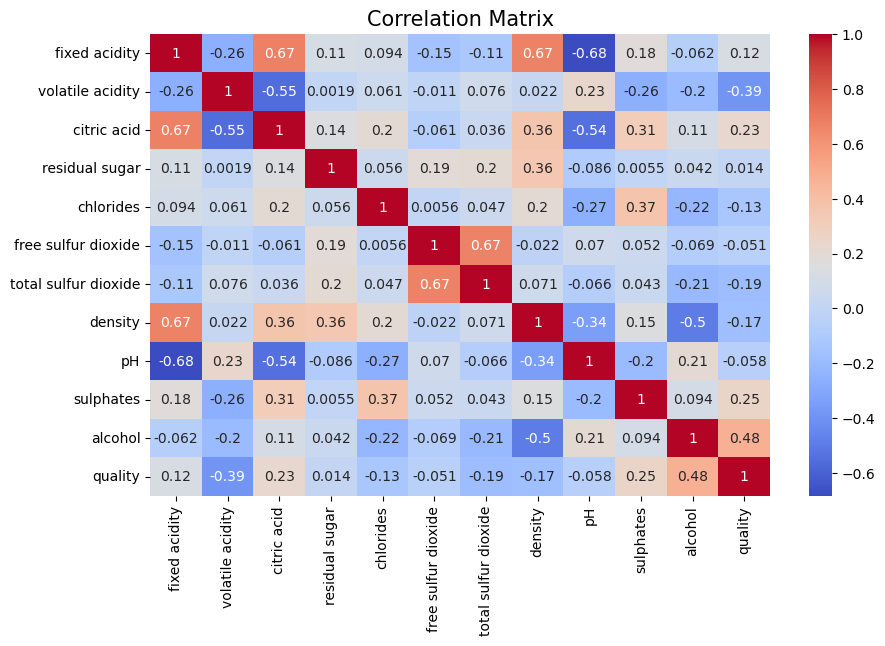

In [ ]:
# --- 1. Basic info ---
# print(wine.head())
# print(wine.info())
# print(wine.describe())
# print("Missing values:\n", wine.isnull().sum())
# print("Duplicate rows:", wine.duplicated().sum())

# --- 2. Target distribution ---
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=wine)
plt.title("Distribution of Wine Quality", fontsize=15)
plt.show()

# --- 3. Feature distributions ---
wine.hist(figsize=(12,8), bins=20)
plt.suptitle("Feature Distributions", fontsize=15)
plt.show()

# --- 4. Boxplot: quality vs key features ---
key_features = ['alcohol', 'sulphates', 'citric acid', 'volatile acidity']
for col in key_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='quality', y=col, data=wine)
    plt.title(f'Wine Quality vs {col}', fontsize=15)
    plt.show()

# --- 5. Correlation heatmap ---
plt.figure(figsize=(10,6))
sns.heatmap(wine.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix", fontsize=15)
plt.show()

## 1.2.3. Bài tập thực hành 2
###  1.2.3.1 Thực hiện trực quan hóa dữ liệu trên tập dữ liệu về bệnh tiểu đường. Dữ liệu lấy tại

https://www.kaggle.com/code/vincentlugat/pima-indians-diabetes-eda-prediction-0-906


Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Duplicate rows: 0


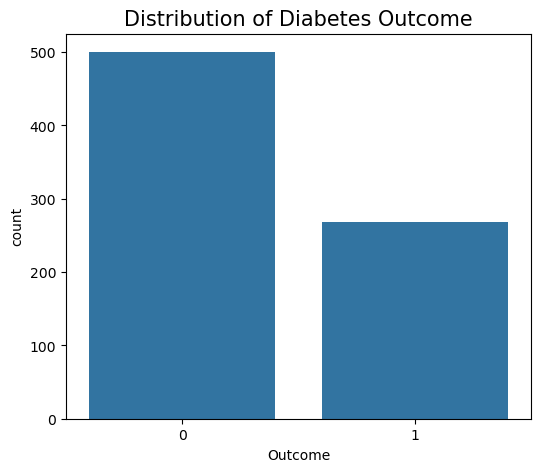

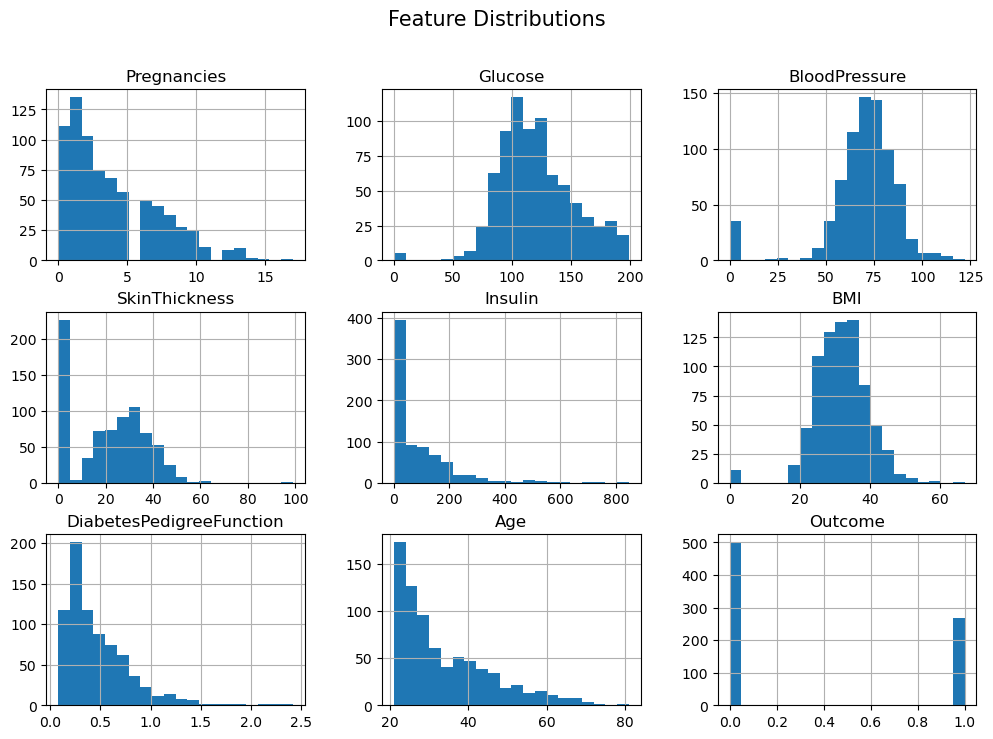

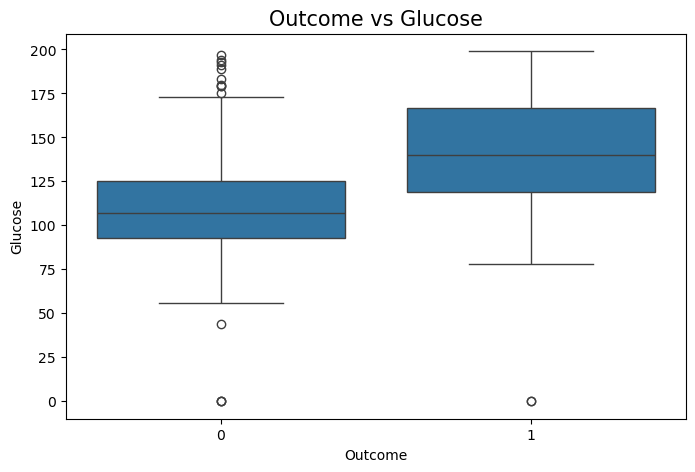

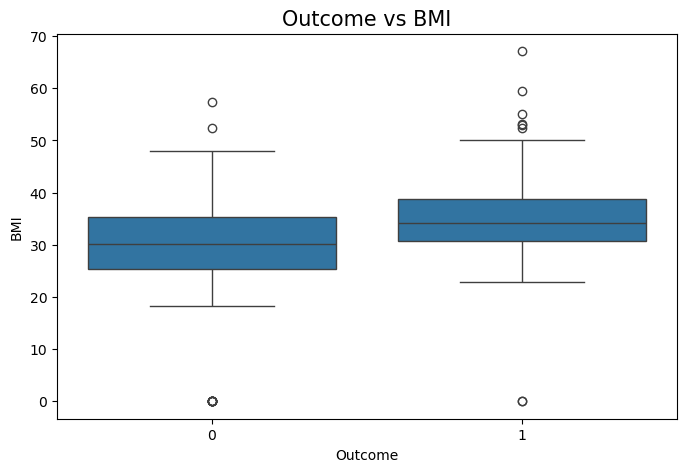

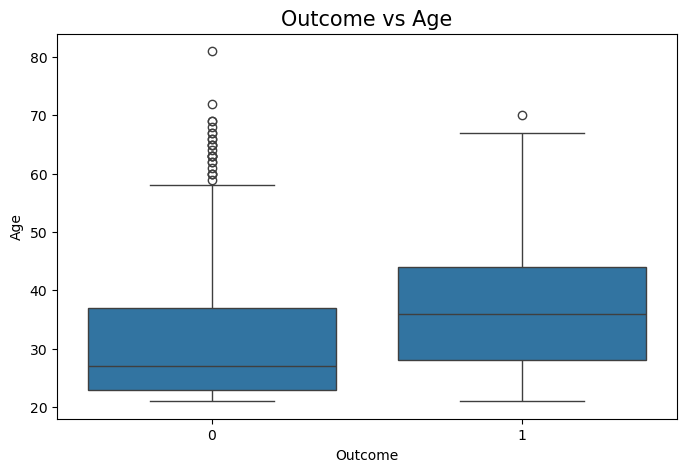

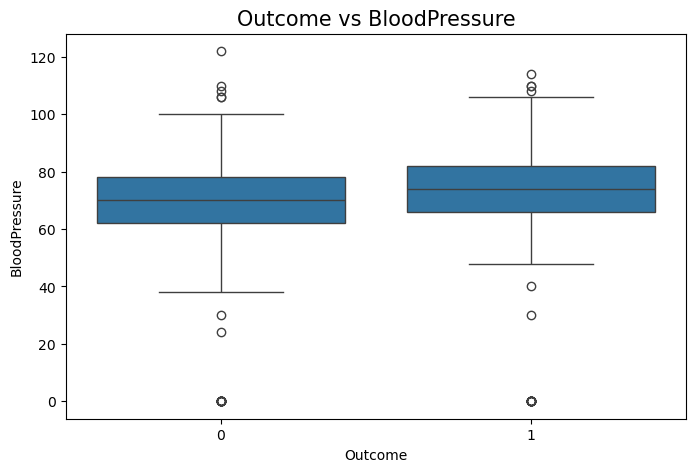

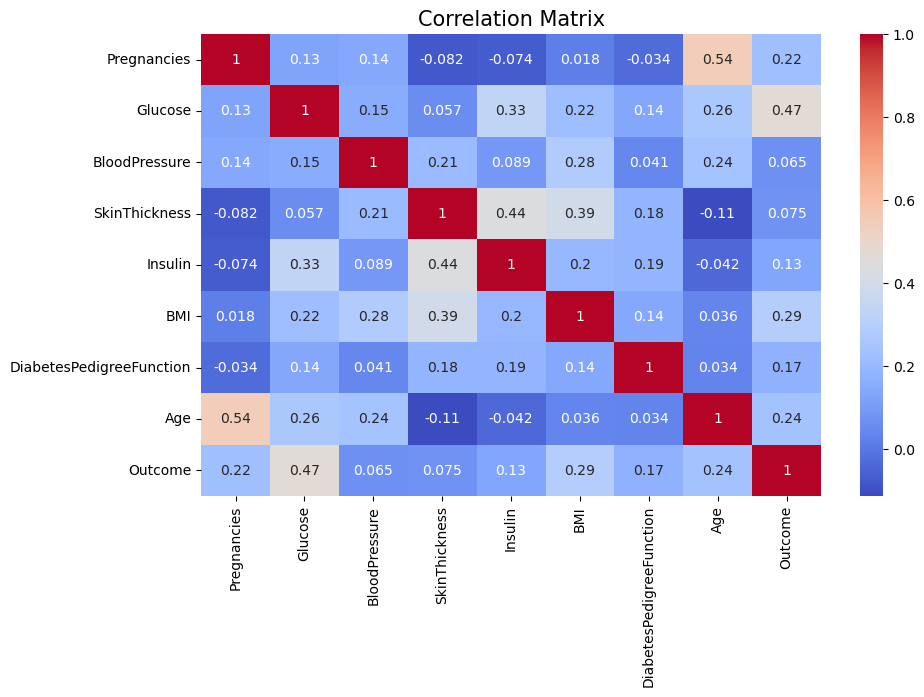

In [ ]:
# ----------------------------
# 2. Diabetes Dataset EDA
# ----------------------------

# --- 1. Basic info ---
#print(diabetes.head())
#print(diabetes.info())
#print(diabetes.describe())
print("Missing values:\n", diabetes.isnull().sum())
print("Duplicate rows:", diabetes.duplicated().sum())

# --- 2. Target distribution ---
plt.figure(figsize=(6,5))
sns.countplot(x='Outcome', data=diabetes)
plt.title("Distribution of Diabetes Outcome", fontsize=15)
plt.show()

# --- 3. Feature distributions ---
diabetes.hist(figsize=(12,8), bins=20)
plt.suptitle("Feature Distributions", fontsize=15)
plt.show()

# --- 4. Boxplot: Outcome vs key features ---
key_features = ['Glucose', 'BMI', 'Age', 'BloodPressure']
for col in key_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Outcome', y=col, data=diabetes)
    plt.title(f'Outcome vs {col}', fontsize=15)
    plt.show()

# --- 5. Correlation heatmap ---
plt.figure(figsize=(10,6))
sns.heatmap(diabetes.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix", fontsize=15)
plt.show()

### 1.2.3.2 Thực hiện EDA trên tập dữ liệu mua sắm tại siêu thị. Tập dữ liệu lấy từ
https://www.kaggle.com/code/rajatkumar30/eda-online-retail

<class 'pandas.core.frame.DataFrame'>
Index: 530104 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   CustomerID   397884 non-null  float64       
 1   InvoiceNo    530104 non-null  object        
 2   StockCode    530104 non-null  object        
 3   Quantity     530104 non-null  int64         
 4   UnitPrice    530104 non-null  float64       
 5   Description  530104 non-null  object        
 6   InvoiceDate  530104 non-null  datetime64[ns]
 7   Country      530104 non-null  object        
 8   TotalAmount  530104 non-null  float64       
 9   Sales        530104 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(4)
memory usage: 44.5+ MB


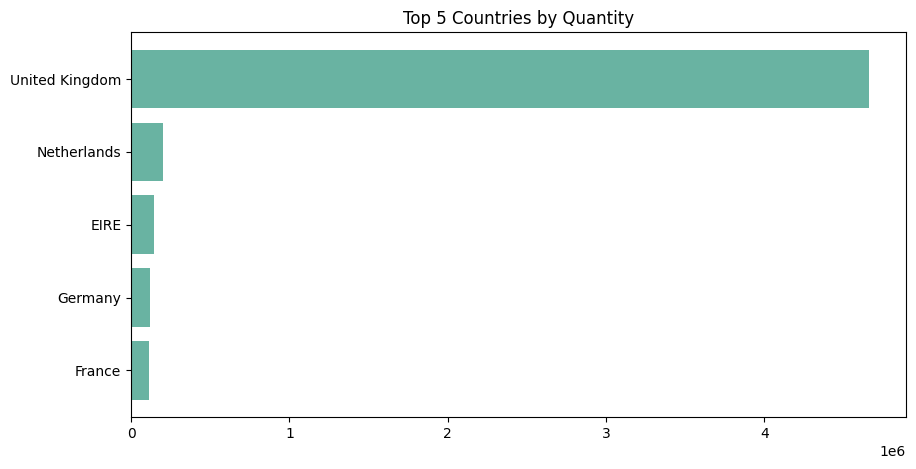

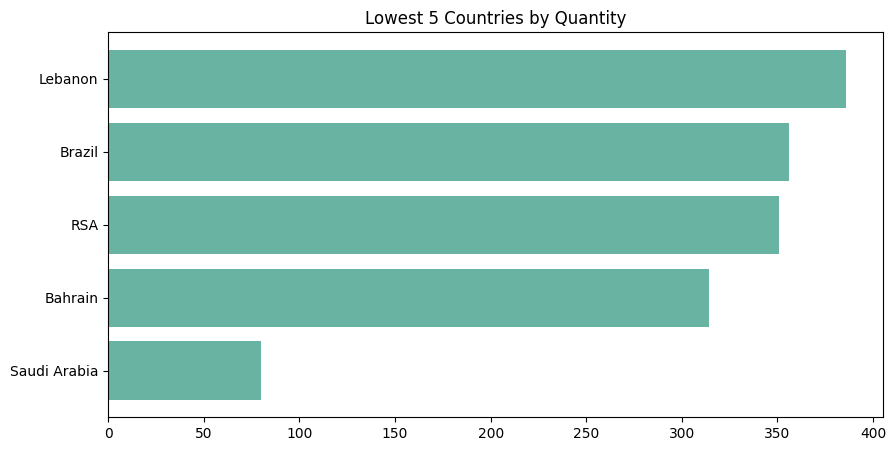

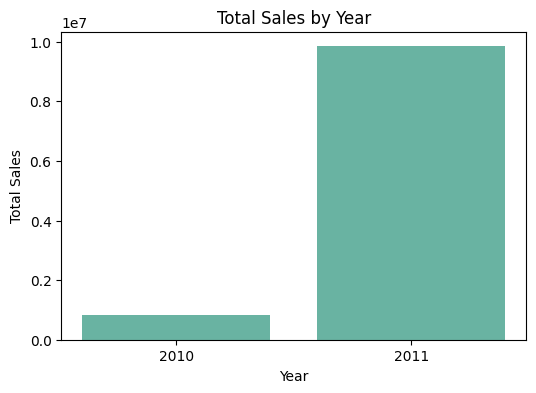

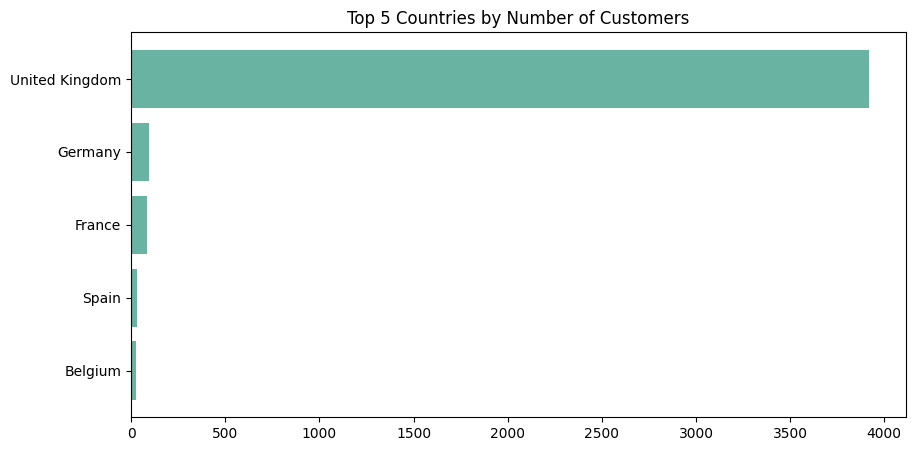

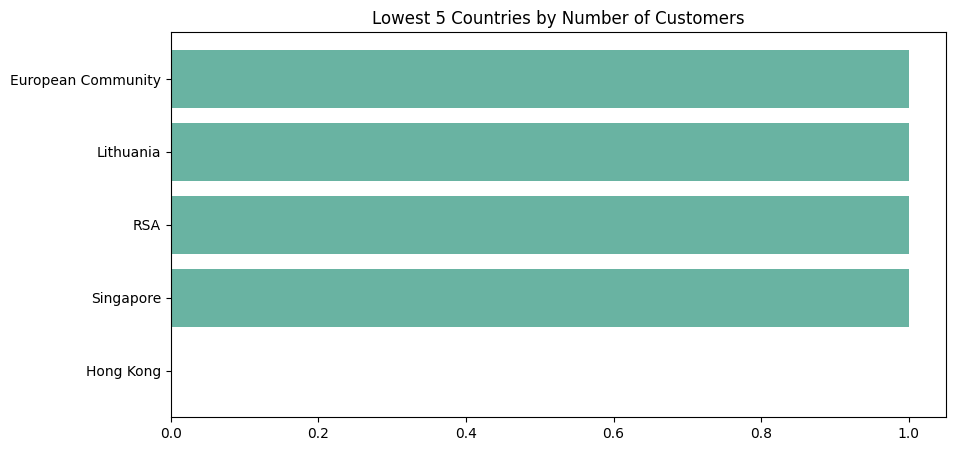

,Country,Sales,Quantity
0,Australia,138521.31,83901
1,Austria,10198.68,4881
2,Bahrain,754.14,314
3,Belgium,41196.34,23237
4,Brazil,1143.60,356


In [ ]:

# =========================================================
# 2. DATA CLEANING
# =========================================================

# Select required columns
online_retail = online_retail[
    ['CustomerID','InvoiceNo','StockCode',
     'Quantity','UnitPrice','Description',
     'InvoiceDate','Country']
]

# Remove invalid transactions (returns, zero values)
online_retail = online_retail[
    (online_retail['Quantity'] > 0) &
    (online_retail['UnitPrice'] > 0)
]

# Create revenue columns
online_retail['TotalAmount'] = online_retail['Quantity'] * online_retail['UnitPrice']
online_retail['Sales'] = online_retail['TotalAmount']

# Convert datetime
online_retail['InvoiceDate'] = pd.to_datetime(online_retail['InvoiceDate'])

# =========================================================
# BASIC CHECKS
# =========================================================

online_retail.isnull().sum()
online_retail.describe(include='all')
online_retail.info()

# =========================================================
# COUNTRY ANALYSIS (TOTAL QUANTITY)
# =========================================================

country_price = online_retail.groupby('Country')['Quantity'].sum().reset_index()
country_price = country_price.sort_values(by='Quantity', ascending=False)

country_price

# -------------------------
# TOP 5 COUNTRIES
# -------------------------

top5 = country_price.head(5)

plt.figure(figsize=(10,5))
plt.barh(top5['Country'], top5['Quantity'], color="#69b3a2")
plt.gca().invert_yaxis()
plt.title("Top 5 Countries by Quantity")
plt.show()

# -------------------------
# LOWEST 5 COUNTRIES
# -------------------------

low5 = country_price.tail(5)

plt.figure(figsize=(10,5))
plt.barh(low5['Country'], low5['Quantity'], color="#69b3a2")
plt.gca().invert_yaxis()
plt.title("Lowest 5 Countries by Quantity")
plt.show()

# =========================================================
# YEAR ANALYSIS
# =========================================================

online_retail['Year'] = online_retail['InvoiceDate'].dt.year

year_sales = online_retail.groupby('Year')['TotalAmount'].sum().reset_index()

plt.figure(figsize=(6,4))

plt.bar(
    year_sales['Year'].astype(str),
    year_sales['TotalAmount'],
    color="#69b3a2"
)

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

# =========================================================
# CUSTOMER ANALYSIS 
# =========================================================

# Number of unique customers per country (CORRECT METHOD)
cus_id = online_retail.groupby('Country')['CustomerID'].nunique().reset_index()

cus_id = cus_id.sort_values(by='CustomerID', ascending=False)

cus_id

# -------------------------
# TOP 5 COUNTRIES BY CUSTOMERS
# -------------------------

top5 = cus_id.head(5)

plt.figure(figsize=(10,5))
plt.barh(top5['Country'], top5['CustomerID'], color="#69b3a2")
plt.gca().invert_yaxis()
plt.title("Top 5 Countries by Number of Customers")
plt.show()

# -------------------------
# LOW 5 COUNTRIES BY CUSTOMERS
# -------------------------

low5 = cus_id.tail(5)

plt.figure(figsize=(10,5))
plt.barh(low5['Country'], low5['CustomerID'], color="#69b3a2")
plt.gca().invert_yaxis()
plt.title("Lowest 5 Countries by Number of Customers")
plt.show()

# =========================================================
# PRODUCT ANALYSIS
# =========================================================

avg_sales = online_retail.groupby(['StockCode','Description']).agg({
    'TotalAmount': 'sum',
    'Quantity': 'sum'
}).reset_index()

avg_sales = avg_sales.sort_values(by='TotalAmount', ascending=False)

avg_sales.head()

# =========================================================
# DATA FOR GLOBE VISUALIZATION (READY FOR NEXT STEP)
# =========================================================

country_sales = online_retail.groupby('Country', as_index=False).agg({
    'Sales': 'sum',
    'Quantity': 'sum'
})

country_sales.head()


In [17]:
import plotly.express as px
import pycountry

# =========================================================
# GLOBE DATA PREP (from online_retail)
# =========================================================

globe_df = online_retail.groupby('Country', as_index=False).agg({
    'Sales': 'sum',
    'Quantity': 'sum'
})

# =========================================================
# COUNTRY → ISO CODE
# =========================================================

exceptions = []

def get_iso3(country):
    try:
        return pycountry.countries.search_fuzzy(country)[0].alpha_3
    except:
        exceptions.append(country)
        return None

globe_df['iso_alpha'] = globe_df['Country'].apply(get_iso3)

# remove unmappable countries
globe_df = globe_df.dropna(subset=['iso_alpha'])

# =========================================================
# GLOBE VISUALIZATION
# =========================================================

fig = px.scatter_geo(
    globe_df,
    locations="iso_alpha",
    color="Sales",
    size="Sales",
    hover_name="Country",
    projection="orthographic",
    color_continuous_scale="Viridis"
)

fig.update_layout(
    title="Online Retail Global Sales Distribution (Globe View)"
)

fig.show()

# 1.3 PHÂN TÍCH ĐƠN BIẾN VÀ HAI BIẾN

## 1.3.1 Ôn lý thuyết

**Q1: Phân tích đơn biến (univariate analysis) là gì? Nó khác gì với phân tích hai biến (bivariate analysis) trong khám phá dữ liệu?**  
A1:  
- **Phân tích đơn biến (Univariate Analysis)**: Phân tích và tóm tắt một biến dữ liệu, tập trung vào phân bố, trung vị, trung bình, độ lệch chuẩn, min, max, outlier.  
- **Phân tích hai biến (Bivariate Analysis)**: Nghiên cứu mối quan hệ giữa hai biến, xác định xu hướng, tương quan, hoặc quan hệ nhân quả.

---

**Q2: Các thước đo thống kê nào thường được sử dụng trong phân tích đơn biến (ví dụ: trung bình, trung vị, mode, độ lệch chuẩn)?**  
A2:  
- Trung bình (Mean)  
- Trung vị (Median)  
- Mode (giá trị xuất hiện nhiều nhất)  
- Độ lệch chuẩn (Standard Deviation)  
- Phương sai (Variance)  
- Min, Max, Range  
- Các phân vị (Q1, Q3, IQR)  

---

**Q3: Trong phân tích hai biến, làm thế nào để xác định mối quan hệ giữa hai biến (ví dụ: tương quan, nhân quả)?**  
A3:  
- **Tương quan (Correlation)**: Xem hai biến thay đổi cùng nhau như thế nào (dương, âm, hoặc không liên quan).  
- **Hiệp biến (Covariance)**: Đo mức độ thay đổi đồng thời giữa hai biến, chưa chuẩn hóa.  
- **Nhân quả (Causation)**: Thường cần phân tích nâng cao (hồi quy, thí nghiệm, kiểm soát biến).  
- Trực quan hóa: scatter plot, line plot, heatmap để nhận dạng mẫu và tương quan.

---

**Q4: Sự khác biệt giữa tương quan (correlation) và hiệp biến (covariance) trong phân tích hai biến là gì?**  
A4:  
- **Covariance**: Cho biết hướng biến đổi chung (dương/âm) nhưng không chuẩn hóa, giá trị phụ thuộc đơn vị dữ liệu.  
- **Correlation**: Chuẩn hóa covariance, nằm trong [-1, 1], dễ so sánh giữa các cặp biến.

---

**Q5: Khi nào nên sử dụng biểu đồ trực quan hóa trong phân tích đơn biến so với phân tích hai biến?**  
A5:  
- **Đơn biến**: Histogram, boxplot, bar chart, pie chart, dùng để quan sát phân bố, outlier, giá trị trung tâm.  
- **Hai biến**: Scatter plot, line plot, heatmap, boxplot/violin plot, dùng để quan sát mối quan hệ, tương quan hoặc sự khác biệt giữa nhóm.

---

**Q6: Làm thế nào để trực quan hóa mối quan hệ giữa một biến số và một biến phân loại bằng biểu đồ boxplot hoặc violin plot trong Python?**  
A6: Dùng **boxplot** hoặc **violin plot** để so sánh phân bố của biến số theo từng nhóm phân loại.  
- Biểu đồ hiển thị trung vị, tứ phân vị, outlier.  
- Violin plot bổ sung thông tin về mật độ dữ liệu trong từng nhóm.

---

**Q7: Đoạn code mẫu để tạo biểu đồ scatter plot hoặc heatmap để phân tích mối quan hệ giữa hai biến?**  
A7: Trực quan hóa bằng **scatter plot** để xem mối tương quan giữa hai biến số, **heatmap** để xem ma trận tương quan giữa nhiều biến. (Chi tiết code không yêu cầu ở đây)

## 1.3.2. Bài làm mẫu

### Bài toán 1: Thực hiện các nhiệm vụ trong bài toán 1 để làm quen với các hàm và thư viện hỗ trợ phân tích dữ liệu đơn biến. Bài toán này được thực hiện trên 2 tập dữ liệu là tập dữ liệu về chim cánh cụt và tập dữ liệu giá nhà.

##### Nhiệm vụ 1: phân tích dữ liệu đơn biến trên dữ liệu về chim cánh cụt lấy tại

https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

In [ ]:
#1. Import thư viện và nạp dữ liệu
penguins_data = penguins_data[['Species','Culmen Length (mm)']]

<Axes: xlabel='Culmen Length (mm)', ylabel='Count'>

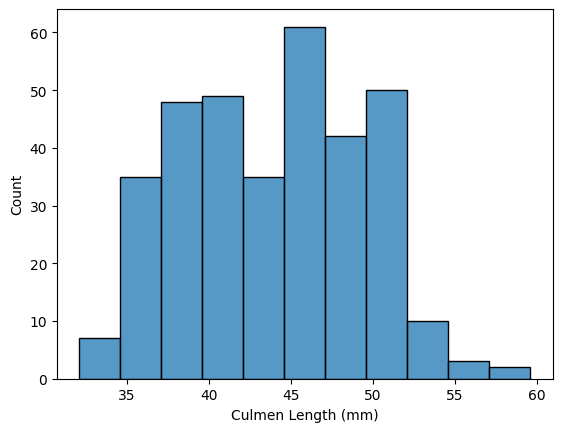

In [26]:
#2. Phân tích đơn biến bằng Histogram
sns.histplot( data = penguins_data, x= penguins_data["Culmen Length (mm)"])

Text(0.5, 1.0, 'Univariate analysis of Culmen Length')

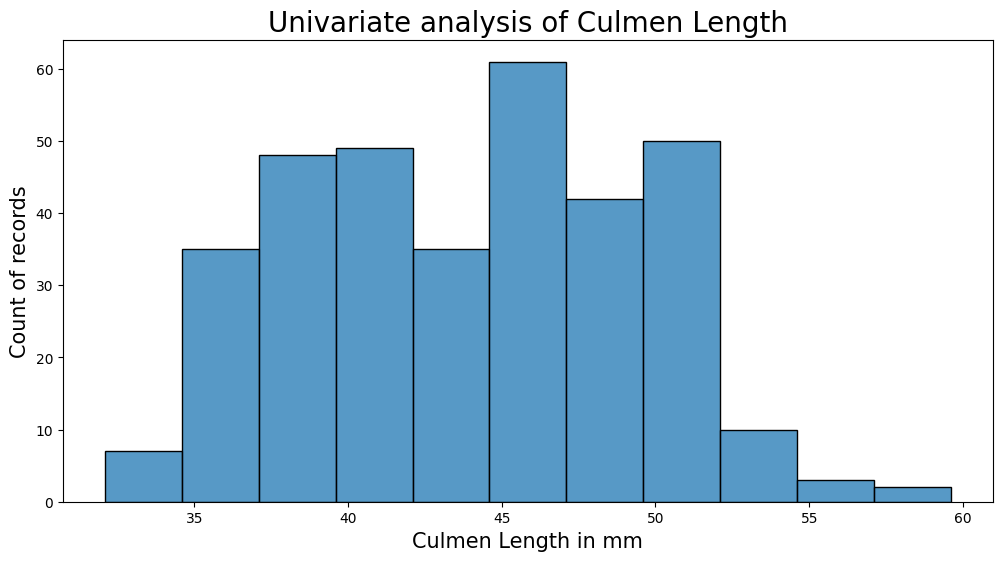

In [4]:
# case 2: advanced
plt.figure(figsize= (12,6))
ax = sns.histplot( data = penguins_data, x=penguins_data["Culmen Length (mm)"])
ax.set_xlabel('Culmen Length in mm',fontsize = 15)
ax.set_ylabel('Count of records', fontsize = 15)
ax.set_title('Univariate analysis of Culmen Length',fontsize= 20)

<Axes: xlabel='Species', ylabel='count'>

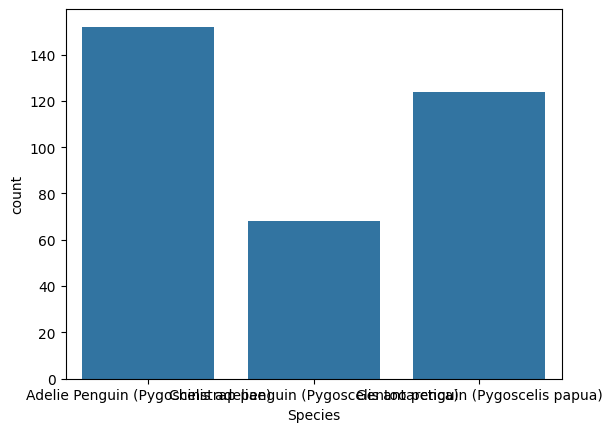

In [5]:
#3. Phân tích đơn biến bằng bar chart
# case 1: basic
sns.countplot(data = penguins_data, x= penguins_data['Species'])


Text(0.5, 1.0, 'Univariate analysis of Culmen Length')

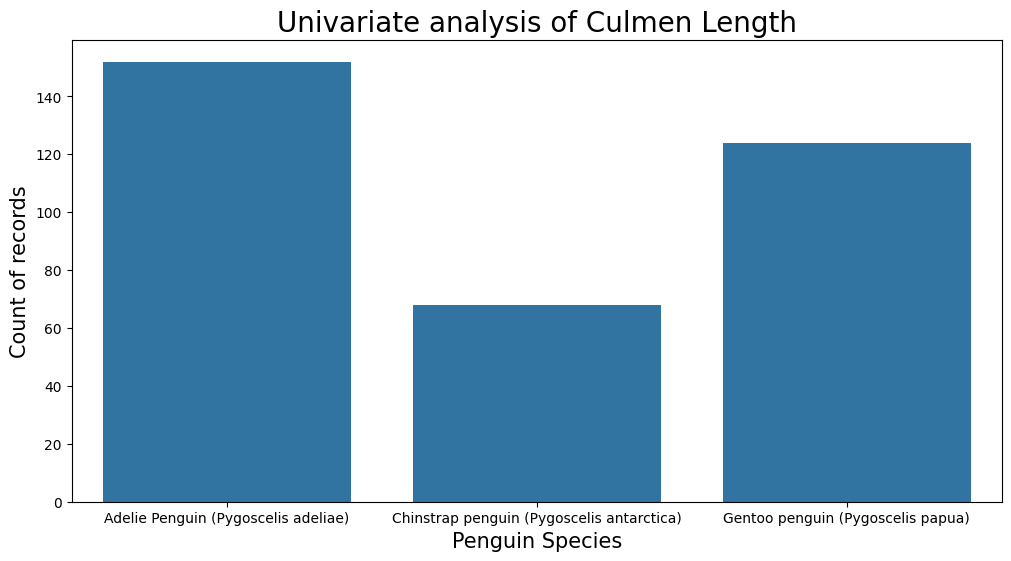

In [6]:
# case 2: advanced
plt.figure(figsize= (12,6))
ax = sns.countplot(data = penguins_data, x= penguins_data['Species'])
ax.set_xlabel('Penguin Species',fontsize = 15)
ax.set_ylabel('Count of records',fontsize = 15)
ax.set_title('Univariate analysis of Penguin Species', fontsize= 20)
ax.set_title('Univariate analysis of Culmen Length', fontsize= 20)

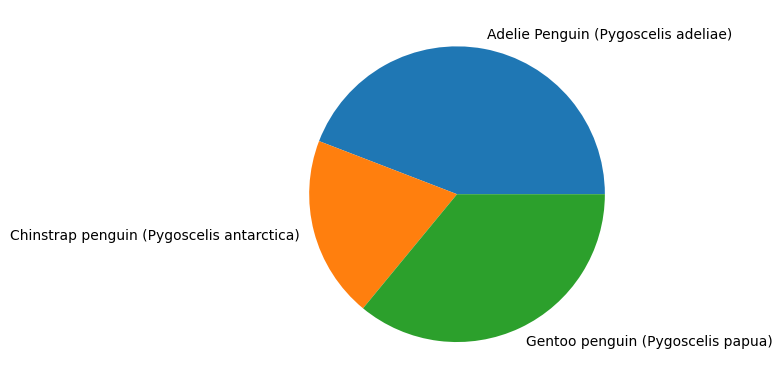

In [7]:
#4. Phân tích đơn biến bằng biểu đồ tròn (Pie-chart)  
penguins_group = penguins_data.groupby('Species').count()
penguins_group = penguins_group.reset_index()

# case 1: basic
plt.pie(penguins_group["Culmen Length (mm)"], labels = penguins_group['Species'])
plt.show()

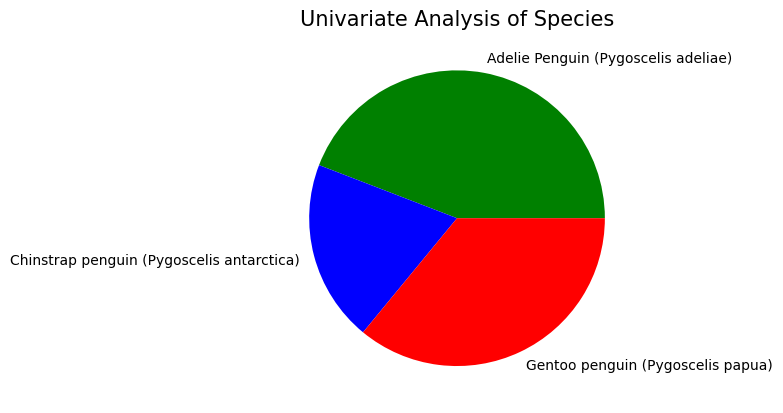

In [8]:
# case 2: advanced
cols = ['g', 'b', 'r']
plt.pie(penguins_group["Culmen Length (mm)"], labels = penguins_group['Species'],colors = cols)
plt.title('Univariate Analysis of Species', fontsize=15)
plt.show()

#### Nhiệm vụ 2: Phân tích dữ liệu đơn biến trên dữ liệu giá nhà lấy từ
https://www.kaggle.com/datasets/thomasnibb/amsterdam-house-price-prediction

In [9]:
#1. Import thư viện, nạp dữ liệu giá nhà và phân tích đơn biến dựa vào boxplot
houseprices_data = houseprices_data[['Zip','Price','Area','Room']]

<Axes: xlabel='Price'>

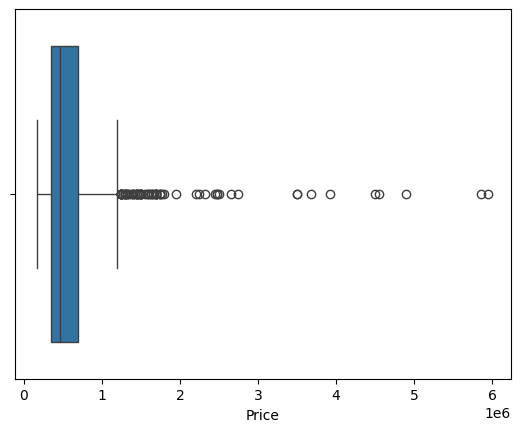

In [10]:
    # case 1: Create a boxplot using the boxplot method
sns.boxplot(data = houseprices_data, x= houseprices_data["Price"])

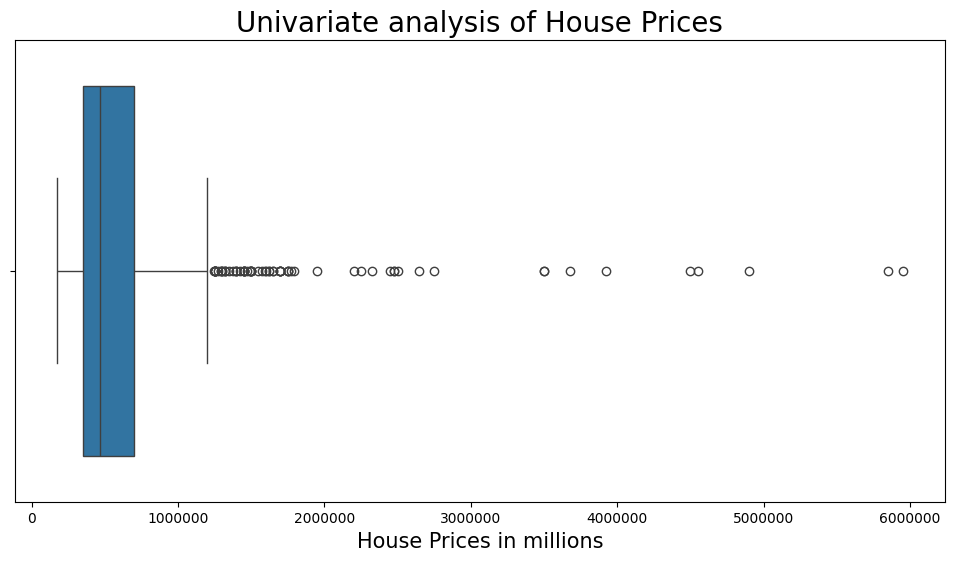

In [11]:
    # case 2: advanced
plt.figure(figsize= (12,6))
ax = sns.boxplot(data = houseprices_data, x= houseprices_data["Price"])
ax.set_xlabel('House Prices in millions',fontsize = 15)
ax.set_title('Univariate analysis of House Prices', fontsize= 20)
plt.ticklabel_format(style='plain', axis='x')

<Axes: xlabel='Price'>

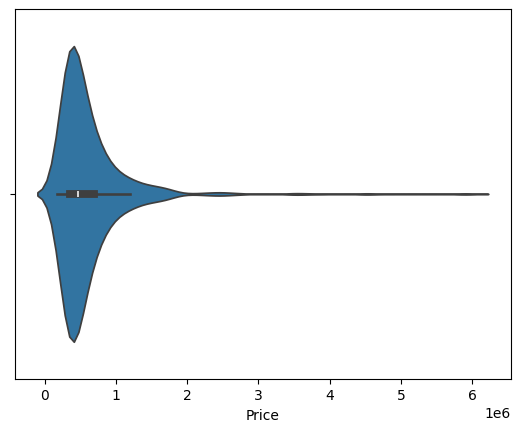

In [12]:
# 2. Phân tích dữ liệu đơn biến dựa vào violin plot
    # case 1: basic
sns.violinplot(data = houseprices_data, x= houseprices_data["Price"])

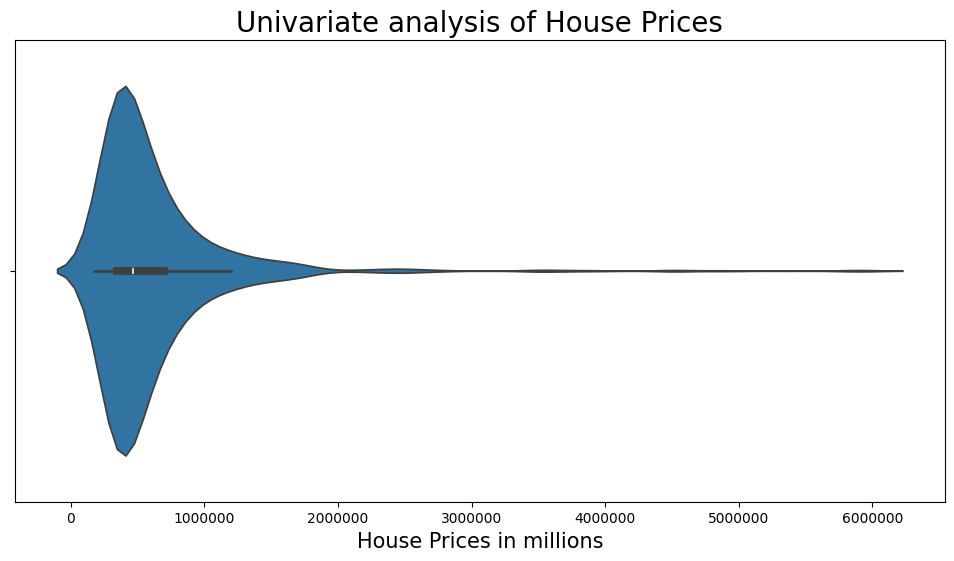

In [13]:
    # case 2: advanced
plt.figure(figsize= (12,6))
ax = sns.violinplot(data = houseprices_data, x=houseprices_data["Price"])
ax.set_xlabel('House Prices in millions',fontsize = 15)
ax.set_title('Univariate analysis of House Prices', fontsize= 20)
plt.ticklabel_format(style='plain', axis='x')

In [14]:
# 3. Phân tích dữ liệu đơn biến dựa vào bản tóm tắt dữ liệu
houseprices_data.describe()

,Price,Area,Room
count,9.200000e+02,924.000000,924.000000
mean,6.220654e+05,95.952381,3.571429
std,5.389942e+05,57.447436,1.592332
min,1.750000e+05,21.000000,1.000000
25%,3.500000e+05,60.750000,3.000000
50%,4.670000e+05,83.000000,3.000000
75%,7.000000e+05,113.000000,4.000000
max,5.950000e+06,623.000000,14.000000


### Bài toán 2: Thực hiện các nhiệm vụ trong bài toán 2 để làm quen với việc phân tích hai biến với các hàm trong thư viện scikit-learn.

#### Nhiệm vụ 1: phân tích dữ liệu hai biến trên dữ liệu về chim cánh cụt. Dữ liệu lấy tại
https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

In [27]:
# 1. Import thư viện và chuẩn bị dữ liệu phân tích
penguins_data = pd.read_csv("data/penguins_lter.csv")
penguins_data = penguins_data[['Species','Culmen Length (mm)','Body Mass (g)', 'Sex']]

<Axes: xlabel='Culmen Length (mm)', ylabel='Body Mass (g)'>

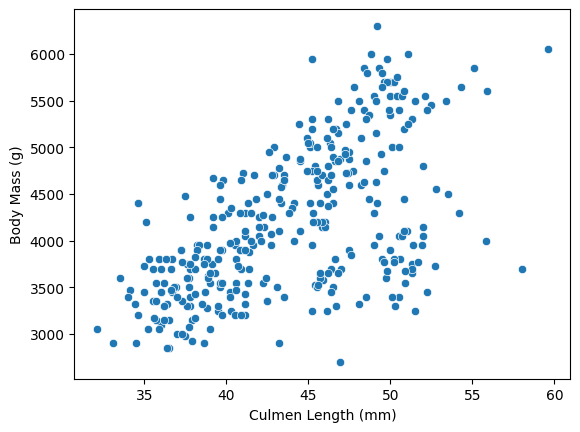

In [28]:
#2. Phân tích dữ liệu 2 biến dựa vào phương pháp scatterplot
    # case 1: basic
sns.scatterplot(data = penguins_data, x= penguins_data["Culmen Length (mm)"], y= penguins_data['Body Mass (g)'])

Text(0.5, 1.0, 'Bivariate analysis of Culmen Length and body mass')

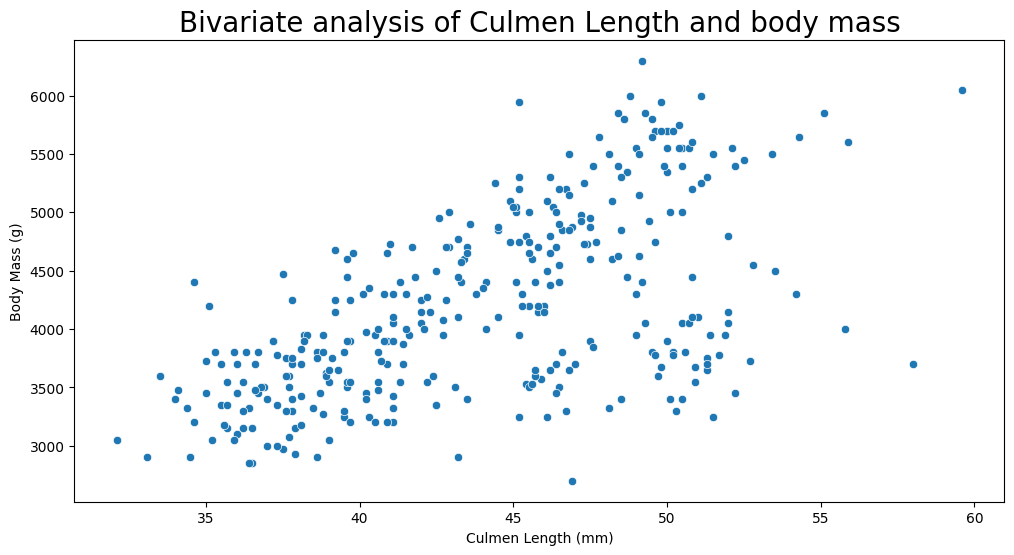

In [29]:
# case 2: advanced
plt.figure(figsize= (12,6))
ax = sns.scatterplot(data = penguins_data, x= penguins_data["Culmen Length (mm)"], y= penguins_data['Body Mass (g)'])
ax.set_title('Bivariate analysis of Culmen Length and body mass', fontsize=20)

In [30]:
#3. Phân tích 2 biến dựa vào bảng crosstab/two-way
pd.crosstab(index= penguins_data['Species'], columns= penguins_data['Sex'])

Sex,.,FEMALE,MALE
Species,,,
Adelie Penguin (Pygoscelis adeliae),0,73,73
Chinstrap penguin (Pygoscelis antarctica),0,34,34
Gentoo penguin (Pygoscelis papua),1,58,61


In [31]:
#4. Phân tích 2 biến sử dụng pivot_table
pd.pivot_table(penguins_data, values='Culmen Length (mm)', index='Species', aggfunc=np.mean)

C:\Users\Marcus\AppData\Local\Temp\ipykernel_31724\2084695165.py:2: FutureWarning: The provided callable <function mean at 0x00000280E10AAF20> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pd.pivot_table(penguins_data, values='Culmen Length (mm)', index='Species', aggfunc=np.mean)


,Culmen Length (mm)
Species,
Adelie Penguin (Pygoscelis adeliae),38.791391
Chinstrap penguin (Pygoscelis antarctica),48.833824
Gentoo penguin (Pygoscelis papua),47.504878


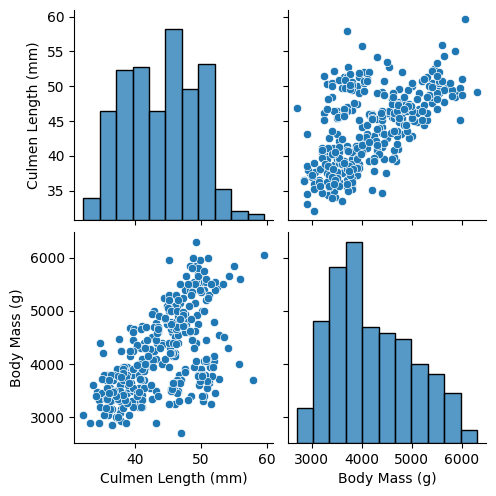

In [32]:
#5. Phân tích 2 biến sử dụng pairplot
sns.pairplot( data = penguins_data)

### Bài toán 3: Thực hiện các nhiệm vụ trong bài toán 3 để làm quen với việc sử dụng các công cụ hỗ trợ EDA tự động.
#### Nhiệm vụ 1: Sử dụng pandas profiling trên dữ liệu Customer Personality Analysis. Dữ liệu lấy tại
https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis


In [34]:
marketing_data = pd.read_csv("data/customer-personality-analysis.csv")
profile = ProfileReport(marketing_data)
profile.to_file("profile_output.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 19.45it/s]
c:\Users\Marcus\miniforge3\envs\ueh_investments2\Lib\site-packages\data_profiling\visualisation\utils.py:73: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.savefig(
c:\Users\Marcus\miniforge3\envs\ueh_investments2\Lib\site-packages\data_profiling\visualisation\utils.py:73: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  plt.savefig(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#### Nhiệm vụ 2: Sử dụng dtale trên dữ liệu Marketing Campaign. Dữ liệu lấy từ
https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

In [36]:
marketing_data = pd.read_csv("data/customer-personality-analysis.csv")
dtale.show(marketing_data).open_browser()

## 1.3.3. Bài tập thực hành 1
Tìm hiểu các tính năng và cách sử dụng sản phẩm SweetViz (https://pypi.org/project/sweetviz) áp dụng
trên tập dữ liệu Marketing Campaign

In [40]:
import sweetviz as sv

marketing_report = sv.analyze(marketing)
marketing_report.show_html() # Default arguments will generate to "SWEETVIZ_REPORT.html"

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## 1.3.4. Bài tập thực hành 2
Tìm hiểu các tính năng và cách sử dụng sản phẩm AutoViz (https://pypi.org/project/autoviz) áp dụng trên
tập dữ liệu Marketing Campaign

In [ ]:
marketing_data = pd.read_csv(
    "data/customer-personality-analysis.csv",
    sep="\t"
)

print(marketing_data.shape)
print(marketing_data.head())

(2240, 29)
    ID   Year_Birth  Education  Marital_Status  Income   Kidhome  Teenhome  \
0  5524     1957     Graduation      Single     58138.0     0         0      
1  2174     1954     Graduation      Single     46344.0     1         1      
2  4141     1965     Graduation    Together     71613.0     0         0      
3  6182     1984     Graduation    Together     26646.0     1         0      
4  5324     1981            PhD     Married     58293.0     1         0      

  Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
0  04-09-2012    58        635       88            546              172         
1  08-03-2014    38         11        1              6                2         
2  21-08-2013    26        426       49            127              111         
3  10-02-2014    26         11        4             20               10         
4  19-01-2014    94        173       43            118               46         

   MntSweetProducts  MntGoldProds

In [72]:
import matplotlib.pyplot as plt
from autoviz import AutoViz_Class

AV = AutoViz_Class()

dft = AV.AutoViz(
    "",
    sep=",",
    depVar="",
    dfte=marketing_data,
    header=0,
    verbose=0,   # IMPORTANT: turn OFF logs
    lowess=False,
    chart_format="svg",
    max_rows_analyzed=150000,
    max_cols_analyzed=30,
    save_plot_dir=None
)

plt.close('all')

Shape of your Data Set loaded: (2240, 29)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    29 Predictors classified...
        3 variable(s) removed since they were ID or low-information variables
    All variables classified into correct types.


,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
ID,int64,0.000000,100,0.000000,11191.000000,Possible ID column: drop before modeling step.
Year_Birth,int64,0.000000,2,1893.000000,1996.000000,Column has 3 outliers greater than upper bound (2004.00) or lower than lower bound(1932.00). Cap them or remove them.
Education,object,0.000000,0,,,No issue
Marital_Status,object,0.000000,0,,,"3 rare categories: ['Alone', 'Absurd', 'YOLO']. Group them into a single category or drop the categories."
Income,float64,1.071429,NA,1730.000000,666666.000000,"24 missing values. Impute them with mean, median, mode, or a constant value such as 123., Column has 8 outliers greater than upper bound (118350.50) or lower than lower bound(-14525.50). Cap them or remove them."
Kidhome,int64,0.000000,0,0.000000,2.000000,No issue
Teenhome,int64,0.000000,0,0.000000,2.000000,No issue
Dt_Customer,object,0.000000,29,,,Possible high cardinality column with 663 unique values: Use hash encoding or text embedding to reduce dimension.
Recency,int64,0.000000,4,0.000000,99.000000,No issue
MntWines,int64,0.000000,34,0.000000,1493.000000,Column has 35 outliers greater than upper bound (1225.00) or lower than lower bound(-697.00). Cap them or remove them.


Could not draw wordcloud plot for Dt_Customer. 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.

All Plots done
Time to run AutoViz = 2 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     C:\Users\Marcus\AppData\Roaming\nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     C:\Users\Marcus\AppData\Roaming\nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     C:\Users\Marcus\AppData\Roaming\nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     C:\Users\Marcus\AppData\Roaming\nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     C:\Users\Marcus\AppData\Roaming\nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_dat

In [ ]:
!pandoc report.md -o report.docx